In [1]:
!pip install focal-loss

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

2025-12-22 01:39:35.132175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766367575.283598      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766367575.329343      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766367575.690044      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766367575.690084      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766367575.690087      55 computation_placer.cc:177] computation placer alr

In [3]:
SEED = 24520152

In [4]:
tf.keras.utils.set_random_seed(SEED)

In [5]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [6]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [8]:
model_name = 'VGG16'
model_name

'VGG16'

In [9]:
preprocess_fn = applications.vgg16.preprocess_input

In [10]:
def build_data_augmentation(SEED=24520152):
    """Create a simple data augmentation pipeline"""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name='data_augmentation')

In [11]:
def get_data_for_fold(k, preprocess_fn, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dirs[0],
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    
    for directory in train_dirs[1:]:
        ds_part = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        train_ds = train_ds.concatenate(ds_part)

    train_ds = train_ds.shuffle(buffer_size=3000, seed=SEED)
    
    AUTOTUNE = tf.data.AUTOTUNE
    data_augmentation = build_data_augmentation()

    def augment_and_preprocess_train(image, label):
        """Apply augmentation and preprocessing to the training set"""
        image = data_augmentation(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def preprocess_val(image, label):
        """Apply preprocessing to the validation set (no augmentation)"""
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds.map(augment_and_preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.map(preprocess_val, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds

In [12]:
def build_vgg16(INPUT_SHAPE=(224, 224, 3), NUM_CLASSES=3, DROPOUT_RATE=0.3):
    """
    Build a VGG16 model with a custom head for classification
    This uses feature extraction (freezing the backbone)

    Args:
        INPUT_SHAPE (tuple): The shape of the input images
        NUM_CLASSES (int): The number of output classes
        DROPOUT_RATE (float): Dropout rate for the classifier head

    Returns:
        tf.keras.Model: The compiled Keras model
    """
    input_layer = tf.keras.Input(shape=INPUT_SHAPE, name="input_layer")

    backbone = applications.VGG16(
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False

    x = backbone(input_layer, training=False)
    x = layers.GlobalAveragePooling2D(name='pooling_layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_layer')(x)
    output_layer = layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name=model_name)
    return model

In [13]:
def train_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50):
    # Build model
    model = build_vgg16()
    print(model.summary())

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    # Set up callbacks
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.keras')

    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    return history

In [14]:
def test_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    history = train_classifier(
        train_ds=train_ds,
        val_ds=val_ds,
        preprocess_fn=preprocess_fn,
        fold_k=fold_k,
    )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_6_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def train_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50, LEARNING_RATE=0.00001):
    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block + 1}_fold_{fold_k}.keras')
    print(model.summary())
    
    backbone = model.get_layer('vgg16')
    backbone.trainable = True
    
    set_trainable = False
    for layer in backbone.layers:
        if layer.name == f'block{block}_conv1':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.keras')
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    return history

In [16]:
def test_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    history = train_block(
        train_ds=train_ds,
        val_ds=val_ds,
        preprocess_fn=preprocess_fn,
        fold_k=fold_k,
        block=block,
    )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block}_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [17]:
acc_b6 = []
acc_b5 = []
acc_b4 = []
acc_b3 = []
acc_b2 = []
acc_b1 = []

Fold: 1 block 6
Found 542 files belonging to 3 classes.


I0000 00:00:1766367588.942404      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

None
Epoch 1/50


I0000 00:00:1766367608.778448     130 service.cc:152] XLA service 0x7b8d0800bd50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766367608.778488     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766367609.283362     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/81 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.2500 - loss: 5.0509  

I0000 00:00:1766367617.827960     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.3918 - loss: 2.8191
Epoch 1: val_accuracy improved from -inf to 0.74539, saving model to /kaggle/working/VGG16_block_6_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 58s 480ms/step - accuracy: 0.3928 - loss: 2.8105 - val_accuracy: 0.7454 - val_loss: 0.4731 - learning_rate: 0.0010
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6477 - loss: 1.0535
Epoch 2: val_accuracy improved from 0.74539 to 0.83026, saving model to /kaggle/working/VGG16_block_6_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.6478 - loss: 1.0524 - val_accuracy: 0.8303 - val_loss: 0.2679 - learning_rate: 0.0010
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7245 - loss: 0.6952
Epoch 3: val_accuracy improved from 0.83026 to 0.84502, saving model to /kaggle/working/VGG16_block_6_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.7246 - loss: 0.6949 - val_accuracy: 0.8450 - val_loss: 0.2988 - learnin

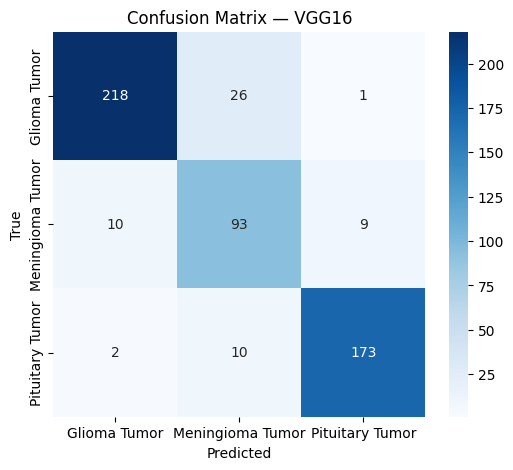

Fold: 1 block 5


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,307 (56.15 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8511 - loss: 0.1596
Epoch 1: val_accuracy improved from -inf to 0.88930, saving model to /kaggle/working/VGG16_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 32s 286ms/step - accuracy: 0.8509 - loss: 0.1597 - val_accuracy: 0.8893 - val_loss: 0.0763 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8546 - loss: 0.1458
Epoch 2: val_accuracy improved from 0.88930 to 0.91144, saving model to /kaggle/working/VGG16_block_5_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.8547 - loss: 0.1455 - val_accuracy: 0.9114 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 3/50
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8958 - loss: 0.0931
Epoch 3: val_accuracy did not improve from 0.91144
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.8956 - loss: 0.0933 - val_accuracy: 0.9059 - val_loss: 0.0638 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━

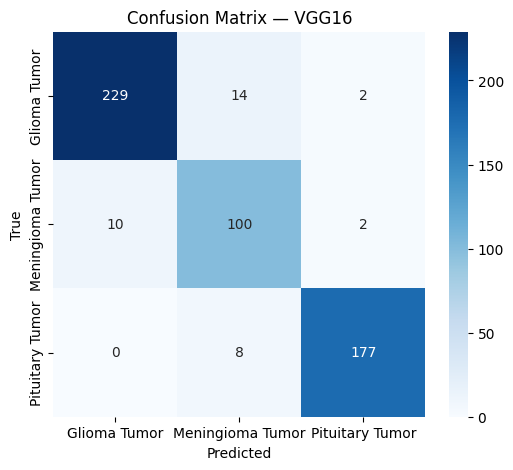

Fold: 1 block 4


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,878,155 (110.16 MB)

 Trainable params: 7,080,963 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,161,928 (54.02 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9462 - loss: 0.0518
Epoch 1: val_accuracy improved from -inf to 0.93173, saving model to /kaggle/working/VGG16_block_4_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 394ms/step - accuracy: 0.9462 - loss: 0.0518 - val_accuracy: 0.9317 - val_loss: 0.0499 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9452 - loss: 0.0432
Epoch 2: val_accuracy did not improve from 0.93173
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9452 - loss: 0.0432 - val_accuracy: 0.9188 - val_loss: 0.0633 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9585 - loss: 0.0299
Epoch 3: val_accuracy improved from 0.93173 to 0.94465, saving model to /kaggle/working/VGG16_block_4_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.9584 - loss: 0.0299 - val_accuracy: 0.9446 - val_loss: 0.0457 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━

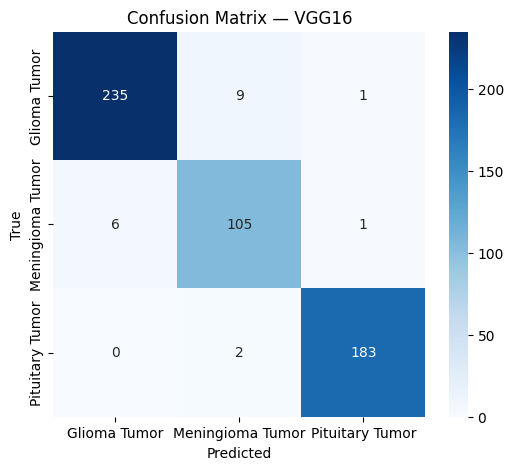

Fold: 1 block 3


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,677,707 (155.17 MB)

 Trainable params: 12,980,739 (49.52 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 25,961,480 (99.04 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9568 - loss: 0.0292
Epoch 1: val_accuracy improved from -inf to 0.96494, saving model to /kaggle/working/VGG16_block_3_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 49s 440ms/step - accuracy: 0.9569 - loss: 0.0292 - val_accuracy: 0.9649 - val_loss: 0.0402 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9716 - loss: 0.0221
Epoch 2: val_accuracy did not improve from 0.96494
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - accuracy: 0.9717 - loss: 0.0221 - val_accuracy: 0.9483 - val_loss: 0.0643 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9796 - loss: 0.0153
Epoch 3: val_accuracy did not improve from 0.96494
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 181ms/step - accuracy: 0.9796 - loss: 0.0153 - val_accuracy: 0.9576 - val_loss: 0.0497 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9871 - loss: 0.0124

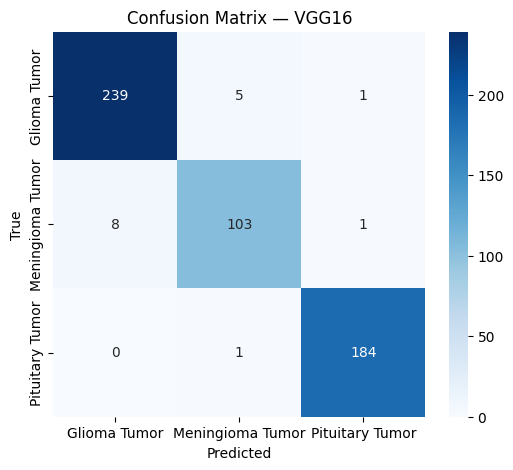

Fold: 1 block 2


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,628,363 (166.43 MB)

 Trainable params: 14,456,067 (55.15 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 28,912,136 (110.29 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9780 - loss: 0.0228
Epoch 1: val_accuracy improved from -inf to 0.96863, saving model to /kaggle/working/VGG16_block_2_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 55s 489ms/step - accuracy: 0.9780 - loss: 0.0228 - val_accuracy: 0.9686 - val_loss: 0.0383 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9889 - loss: 0.0134
Epoch 2: val_accuracy did not improve from 0.96863
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.9888 - loss: 0.0134 - val_accuracy: 0.9686 - val_loss: 0.0341 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9742 - loss: 0.0187
Epoch 3: val_accuracy did not improve from 0.96863
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - accuracy: 0.9743 - loss: 0.0187 - val_accuracy: 0.9613 - val_loss: 0.0390 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9833 - loss: 0.0182

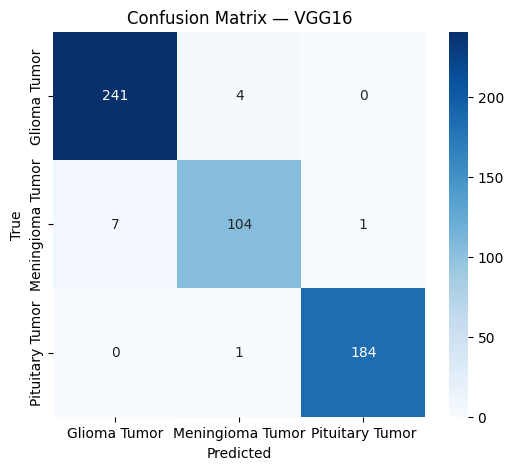

Fold: 1 block 1


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,071,243 (168.12 MB)

 Trainable params: 14,677,507 (55.99 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 29,355,016 (111.98 MB)

None
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.9879 - loss: 0.0122
Epoch 1: val_accuracy improved from -inf to 0.95572, saving model to /kaggle/working/VGG16_block_1_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 564ms/step - accuracy: 0.9879 - loss: 0.0122 - val_accuracy: 0.9557 - val_loss: 0.0454 - learning_rate: 1.0000e-05
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9729 - loss: 0.0238
Epoch 2: val_accuracy improved from 0.95572 to 0.96310, saving model to /kaggle/working/VGG16_block_1_fold_1.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.9729 - loss: 0.0237 - val_accuracy: 0.9631 - val_loss: 0.0554 - learning_rate: 1.0000e-05
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9893 - loss: 0.0084
Epoch 3: val_accuracy did not improve from 0.96310
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.9892 - loss: 0.0085 - val_accuracy: 0.9520 - val_loss: 0.0409 - learning_rate: 1.0000e-05
Epoch 4/50
81/81 ━━━━

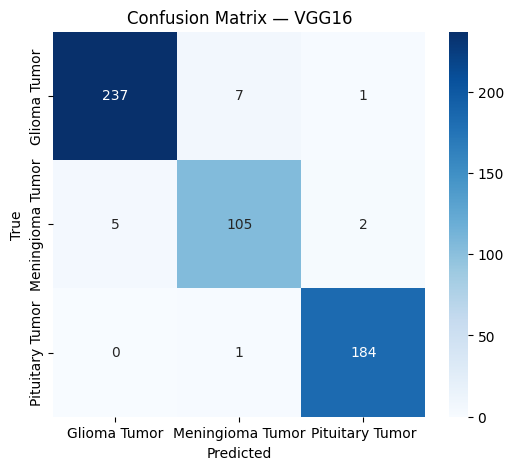

Fold: 2 block 6
Found 679 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,227 (56.14 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3689 - loss: 3.3569
Epoch 1: val_accuracy improved from -inf to 0.67010, saving model to /kaggle/working/VGG16_block_6_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 260ms/step - accuracy: 0.3699 - loss: 3.3433 - val_accuracy: 0.6701 - val_loss: 0.8124 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6130 - loss: 1.1079
Epoch 2: val_accuracy improved from 0.67010 to 0.77761, saving model to /kaggle/working/VGG16_block_6_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.6134 - loss: 1.1064 - val_accuracy: 0.7776 - val_loss: 0.3741 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6994 - loss: 0.7885
Epoch 3: val_accuracy improved from 0.77761 to 0.77909, saving model to /kaggle/working/VGG16_block_6_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.6996 - loss: 0.7878 - val_accuracy: 0.7791 - val_loss: 

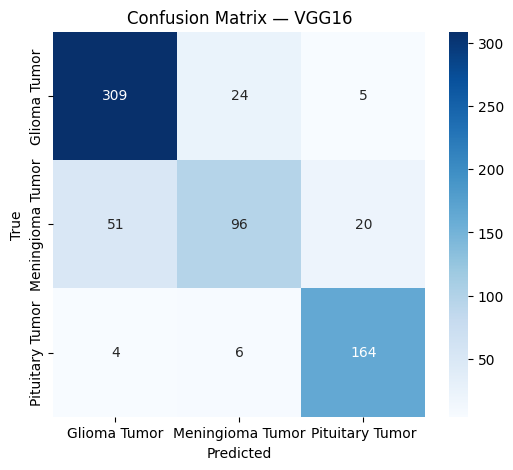

Fold: 2 block 5


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,307 (56.15 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8461 - loss: 0.1962
Epoch 1: val_accuracy improved from -inf to 0.83358, saving model to /kaggle/working/VGG16_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 289ms/step - accuracy: 0.8460 - loss: 0.1960 - val_accuracy: 0.8336 - val_loss: 0.1669 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8562 - loss: 0.1457
Epoch 2: val_accuracy improved from 0.83358 to 0.84389, saving model to /kaggle/working/VGG16_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.8563 - loss: 0.1455 - val_accuracy: 0.8439 - val_loss: 0.1451 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8614 - loss: 0.1132
Epoch 3: val_accuracy improved from 0.84389 to 0.86303, saving model to /kaggle/working/VGG16_block_5_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.8616 - loss: 0.1131 - val_accuracy: 0.8630 - va

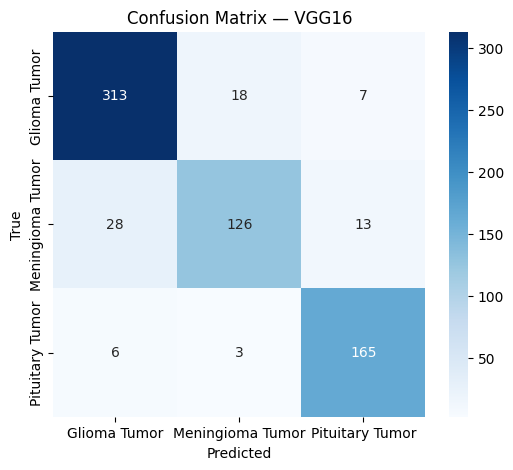

Fold: 2 block 4


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,878,155 (110.16 MB)

 Trainable params: 7,080,963 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,161,928 (54.02 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9224 - loss: 0.0649
Epoch 1: val_accuracy improved from -inf to 0.88071, saving model to /kaggle/working/VGG16_block_4_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 36s 361ms/step - accuracy: 0.9225 - loss: 0.0649 - val_accuracy: 0.8807 - val_loss: 0.1495 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9487 - loss: 0.0373
Epoch 2: val_accuracy improved from 0.88071 to 0.88660, saving model to /kaggle/working/VGG16_block_4_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.9487 - loss: 0.0373 - val_accuracy: 0.8866 - val_loss: 0.1248 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9483 - loss: 0.0459
Epoch 3: val_accuracy did not improve from 0.88660
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.9483 - loss: 0.0458 - val_accuracy: 0.8557 - val_loss: 0.1678 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━

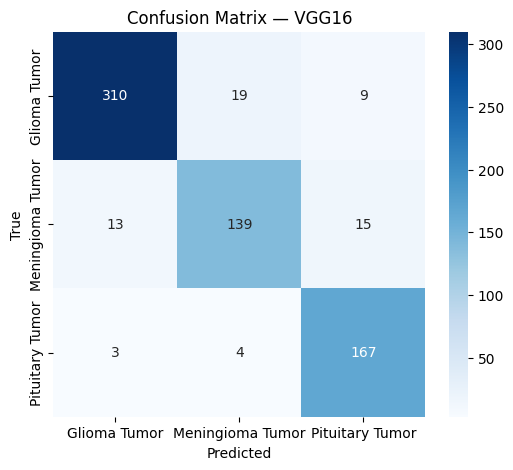

Fold: 2 block 3


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,677,707 (155.17 MB)

 Trainable params: 12,980,739 (49.52 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 25,961,480 (99.04 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9686 - loss: 0.0298
Epoch 1: val_accuracy improved from -inf to 0.90133, saving model to /kaggle/working/VGG16_block_3_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 42s 419ms/step - accuracy: 0.9686 - loss: 0.0298 - val_accuracy: 0.9013 - val_loss: 0.1237 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9730 - loss: 0.0285
Epoch 2: val_accuracy did not improve from 0.90133
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 190ms/step - accuracy: 0.9730 - loss: 0.0285 - val_accuracy: 0.8851 - val_loss: 0.1588 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9719 - loss: 0.0298
Epoch 3: val_accuracy did not improve from 0.90133
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 190ms/step - accuracy: 0.9719 - loss: 0.0298 - val_accuracy: 0.9013 - val_loss: 0.1489 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9667 - loss: 0.0282

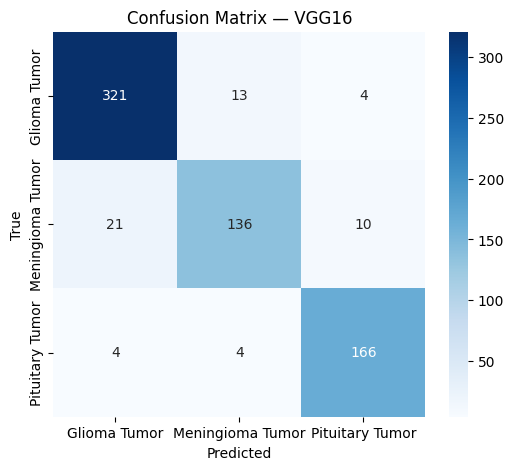

Fold: 2 block 2


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,628,363 (166.43 MB)

 Trainable params: 14,456,067 (55.15 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 28,912,136 (110.29 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9754 - loss: 0.0203
Epoch 1: val_accuracy improved from -inf to 0.89396, saving model to /kaggle/working/VGG16_block_2_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 45s 456ms/step - accuracy: 0.9754 - loss: 0.0203 - val_accuracy: 0.8940 - val_loss: 0.1680 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9846 - loss: 0.0180
Epoch 2: val_accuracy did not improve from 0.89396
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 213ms/step - accuracy: 0.9846 - loss: 0.0180 - val_accuracy: 0.8292 - val_loss: 0.5176 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9670 - loss: 0.0399
Epoch 3: val_accuracy improved from 0.89396 to 0.89838, saving model to /kaggle/working/VGG16_block_2_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.9671 - loss: 0.0397 - val_accuracy: 0.8984 - val_loss: 0.1129 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━

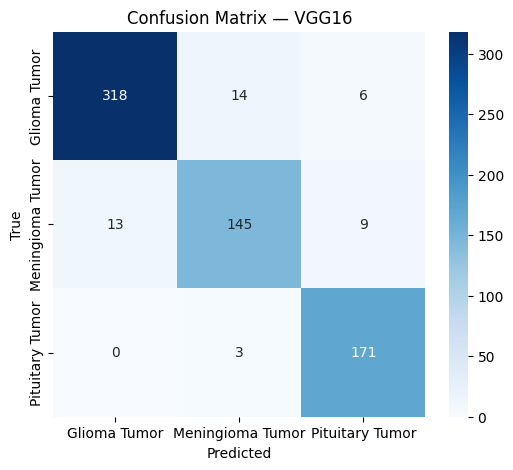

Fold: 2 block 1


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,071,243 (168.12 MB)

 Trainable params: 14,677,507 (55.99 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 29,355,016 (111.98 MB)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9851 - loss: 0.0105
Epoch 1: val_accuracy improved from -inf to 0.91900, saving model to /kaggle/working/VGG16_block_1_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 529ms/step - accuracy: 0.9852 - loss: 0.0105 - val_accuracy: 0.9190 - val_loss: 0.1524 - learning_rate: 1.0000e-05
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9849 - loss: 0.0131
Epoch 2: val_accuracy improved from 0.91900 to 0.93814, saving model to /kaggle/working/VGG16_block_1_fold_2.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 26s 276ms/step - accuracy: 0.9849 - loss: 0.0130 - val_accuracy: 0.9381 - val_loss: 0.1055 - learning_rate: 1.0000e-05
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9907 - loss: 0.0092
Epoch 3: val_accuracy did not improve from 0.93814
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 255ms/step - accuracy: 0.9907 - loss: 0.0092 - val_accuracy: 0.9264 - val_loss: 0.1268 - learning_rate: 1.0000e-05
Epoch 4/50
76/76 ━━━━

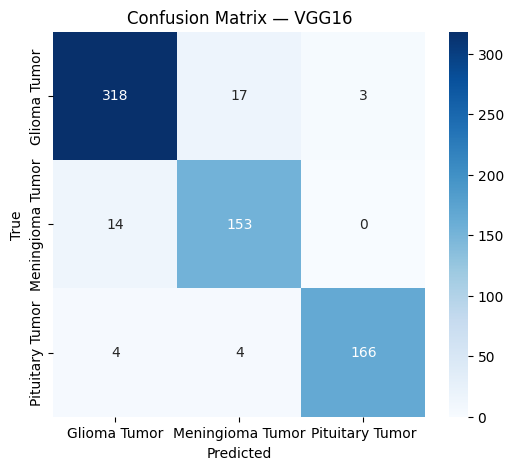

Fold: 3 block 6
Found 572 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,227 (56.14 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4105 - loss: 2.3630
Epoch 1: val_accuracy improved from -inf to 0.72378, saving model to /kaggle/working/VGG16_block_6_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 241ms/step - accuracy: 0.4117 - loss: 2.3559 - val_accuracy: 0.7238 - val_loss: 0.4740 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6630 - loss: 1.0402
Epoch 2: val_accuracy improved from 0.72378 to 0.76923, saving model to /kaggle/working/VGG16_block_6_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - accuracy: 0.6634 - loss: 1.0383 - val_accuracy: 0.7692 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7212 - loss: 0.7584
Epoch 3: val_accuracy improved from 0.76923 to 0.81119, saving model to /kaggle/working/VGG16_block_6_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.7213 - loss: 0.7571 - val_accuracy: 0.8112 - val_loss: 

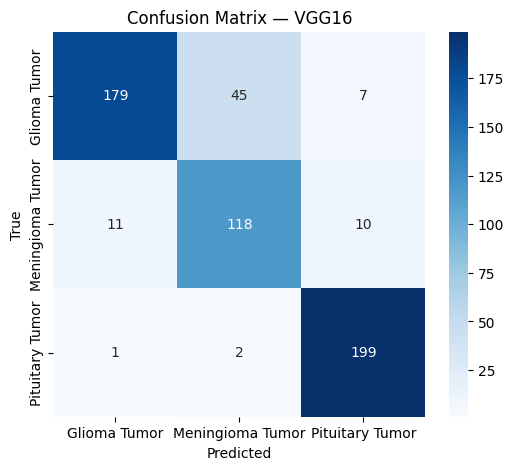

Fold: 3 block 5


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,307 (56.15 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8310 - loss: 0.2022
Epoch 1: val_accuracy improved from -inf to 0.82867, saving model to /kaggle/working/VGG16_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 274ms/step - accuracy: 0.8312 - loss: 0.2017 - val_accuracy: 0.8287 - val_loss: 0.1727 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8579 - loss: 0.1284
Epoch 2: val_accuracy improved from 0.82867 to 0.87063, saving model to /kaggle/working/VGG16_block_5_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.8580 - loss: 0.1283 - val_accuracy: 0.8706 - val_loss: 0.1160 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8933 - loss: 0.0909
Epoch 3: val_accuracy did not improve from 0.87063
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.8933 - loss: 0.0909 - val_accuracy: 0.8619 - val_loss: 0.1371 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

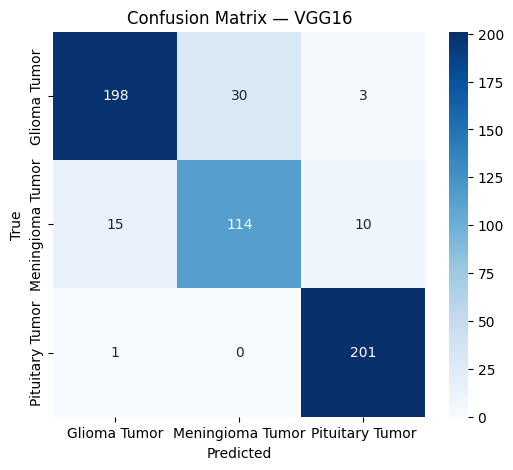

Fold: 3 block 4


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,878,155 (110.16 MB)

 Trainable params: 7,080,963 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,161,928 (54.02 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9314 - loss: 0.0556
Epoch 1: val_accuracy improved from -inf to 0.88112, saving model to /kaggle/working/VGG16_block_4_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 34s 307ms/step - accuracy: 0.9314 - loss: 0.0557 - val_accuracy: 0.8811 - val_loss: 0.1116 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9530 - loss: 0.0431
Epoch 2: val_accuracy improved from 0.88112 to 0.90035, saving model to /kaggle/working/VGG16_block_4_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9530 - loss: 0.0432 - val_accuracy: 0.9003 - val_loss: 0.0886 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9520 - loss: 0.0425
Epoch 3: val_accuracy did not improve from 0.90035
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.9520 - loss: 0.0425 - val_accuracy: 0.8864 - val_loss: 0.1292 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

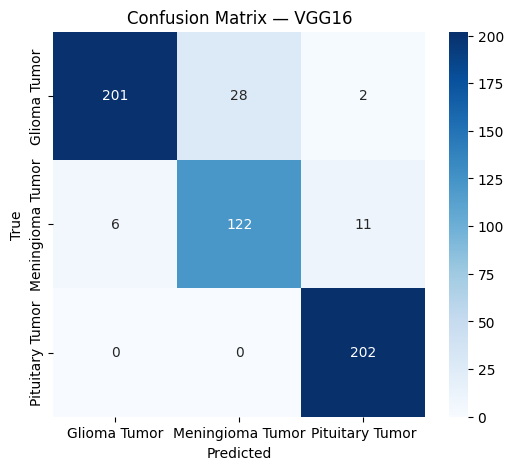

Fold: 3 block 3


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,677,707 (155.17 MB)

 Trainable params: 12,980,739 (49.52 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 25,961,480 (99.04 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.9680 - loss: 0.0254
Epoch 1: val_accuracy improved from -inf to 0.90559, saving model to /kaggle/working/VGG16_block_3_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 352ms/step - accuracy: 0.9680 - loss: 0.0254 - val_accuracy: 0.9056 - val_loss: 0.1558 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9831 - loss: 0.0124
Epoch 2: val_accuracy improved from 0.90559 to 0.91608, saving model to /kaggle/working/VGG16_block_3_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - accuracy: 0.9832 - loss: 0.0124 - val_accuracy: 0.9161 - val_loss: 0.1374 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9750 - loss: 0.0256
Epoch 3: val_accuracy did not improve from 0.91608
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.9750 - loss: 0.0256 - val_accuracy: 0.9161 - val_loss: 0.0960 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

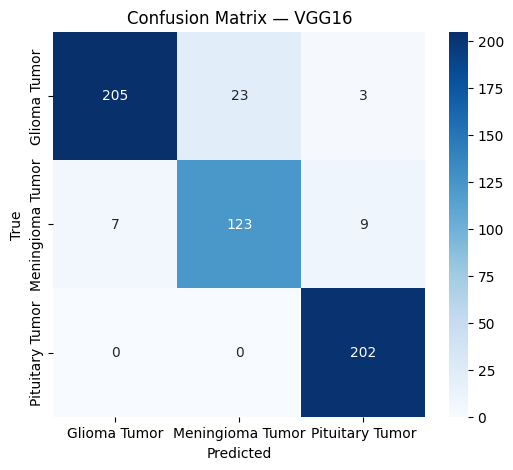

Fold: 3 block 2


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,628,363 (166.43 MB)

 Trainable params: 14,456,067 (55.15 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 28,912,136 (110.29 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9809 - loss: 0.0122
Epoch 1: val_accuracy improved from -inf to 0.90385, saving model to /kaggle/working/VGG16_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 391ms/step - accuracy: 0.9808 - loss: 0.0122 - val_accuracy: 0.9038 - val_loss: 0.1353 - learning_rate: 1.0000e-05
Epoch 2/50
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9862 - loss: 0.0122
Epoch 2: val_accuracy improved from 0.90385 to 0.93182, saving model to /kaggle/working/VGG16_block_2_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - accuracy: 0.9862 - loss: 0.0121 - val_accuracy: 0.9318 - val_loss: 0.1017 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9878 - loss: 0.0127
Epoch 3: val_accuracy did not improve from 0.93182
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.9878 - loss: 0.0127 - val_accuracy: 0.8986 - val_loss: 0.2003 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━

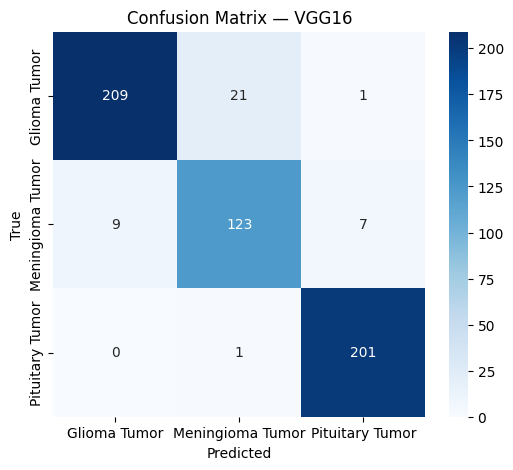

Fold: 3 block 1


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,071,243 (168.12 MB)

 Trainable params: 14,677,507 (55.99 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 29,355,016 (111.98 MB)

None
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9792 - loss: 0.0205
Epoch 1: val_accuracy improved from -inf to 0.92308, saving model to /kaggle/working/VGG16_block_1_fold_3.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 48s 454ms/step - accuracy: 0.9792 - loss: 0.0205 - val_accuracy: 0.9231 - val_loss: 0.0815 - learning_rate: 1.0000e-05
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9896 - loss: 0.0093
Epoch 2: val_accuracy did not improve from 0.92308
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step - accuracy: 0.9897 - loss: 0.0092 - val_accuracy: 0.9108 - val_loss: 0.1991 - learning_rate: 1.0000e-05
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9902 - loss: 0.0093
Epoch 3: val_accuracy did not improve from 0.92308
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step - accuracy: 0.9902 - loss: 0.0094 - val_accuracy: 0.9108 - val_loss: 0.1732 - learning_rate: 1.0000e-05
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9897 - loss: 0.0064

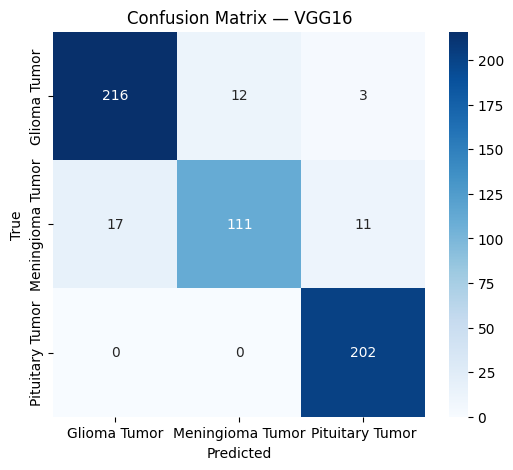

Fold: 4 block 6
Found 628 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 643 files belonging to 3 classes.


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,227 (56.14 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4703 - loss: 2.0863
Epoch 1: val_accuracy improved from -inf to 0.76274, saving model to /kaggle/working/VGG16_block_6_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 248ms/step - accuracy: 0.4709 - loss: 2.0820 - val_accuracy: 0.7627 - val_loss: 0.4957 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6476 - loss: 0.9765
Epoch 2: val_accuracy improved from 0.76274 to 0.81210, saving model to /kaggle/working/VGG16_block_6_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.6479 - loss: 0.9752 - val_accuracy: 0.8121 - val_loss: 0.3637 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7021 - loss: 0.7298
Epoch 3: val_accuracy did not improve from 0.81210
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.7023 - loss: 0.7288 - val_accuracy: 0.8057 - val_loss: 0.4849 - learning_rate: 0.0010
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━

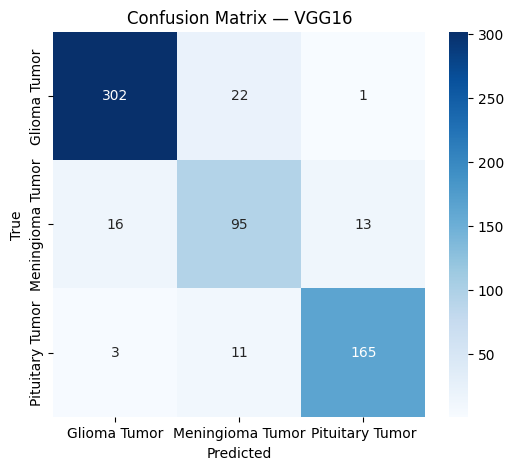

Fold: 4 block 5


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,307 (56.15 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8431 - loss: 0.1514
Epoch 1: val_accuracy improved from -inf to 0.90446, saving model to /kaggle/working/VGG16_block_5_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 276ms/step - accuracy: 0.8431 - loss: 0.1513 - val_accuracy: 0.9045 - val_loss: 0.0904 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8673 - loss: 0.1242
Epoch 2: val_accuracy did not improve from 0.90446
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.8674 - loss: 0.1241 - val_accuracy: 0.8997 - val_loss: 0.0810 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8862 - loss: 0.1024
Epoch 3: val_accuracy did not improve from 0.90446
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.8862 - loss: 0.1023 - val_accuracy: 0.8997 - val_loss: 0.0825 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9050 - loss: 0.0777

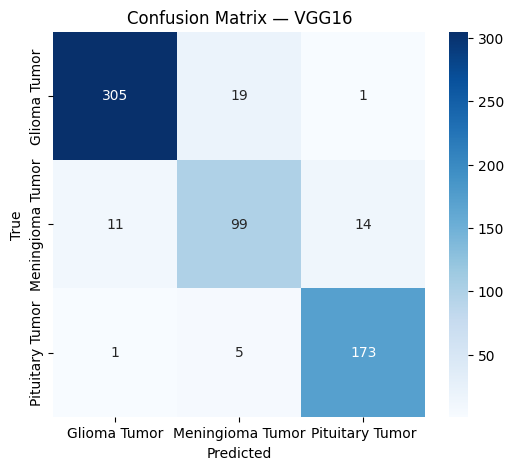

Fold: 4 block 4


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,878,155 (110.16 MB)

 Trainable params: 7,080,963 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,161,928 (54.02 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9110 - loss: 0.0692
Epoch 1: val_accuracy improved from -inf to 0.91083, saving model to /kaggle/working/VGG16_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 318ms/step - accuracy: 0.9110 - loss: 0.0691 - val_accuracy: 0.9108 - val_loss: 0.0765 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9512 - loss: 0.0482
Epoch 2: val_accuracy did not improve from 0.91083
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.9510 - loss: 0.0483 - val_accuracy: 0.8838 - val_loss: 0.1129 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9556 - loss: 0.0379
Epoch 3: val_accuracy improved from 0.91083 to 0.92357, saving model to /kaggle/working/VGG16_block_4_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.9555 - loss: 0.0379 - val_accuracy: 0.9236 - val_loss: 0.0676 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━

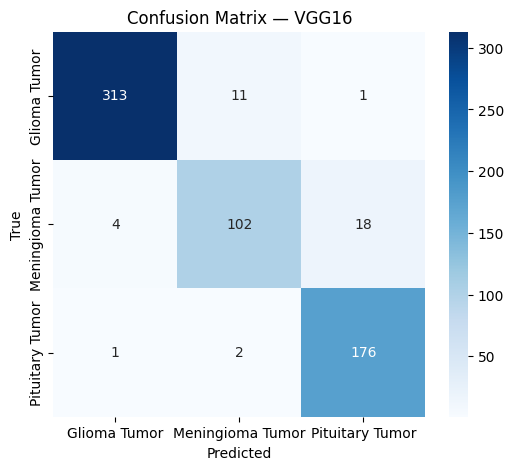

Fold: 4 block 3


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,677,707 (155.17 MB)

 Trainable params: 12,980,739 (49.52 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 25,961,480 (99.04 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9553 - loss: 0.0331
Epoch 1: val_accuracy improved from -inf to 0.94268, saving model to /kaggle/working/VGG16_block_3_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 360ms/step - accuracy: 0.9554 - loss: 0.0330 - val_accuracy: 0.9427 - val_loss: 0.0709 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9776 - loss: 0.0185
Epoch 2: val_accuracy did not improve from 0.94268
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.9776 - loss: 0.0186 - val_accuracy: 0.9220 - val_loss: 0.0980 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9786 - loss: 0.0179
Epoch 3: val_accuracy did not improve from 0.94268
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - accuracy: 0.9785 - loss: 0.0179 - val_accuracy: 0.9172 - val_loss: 0.1153 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9320 - loss: 0.0725

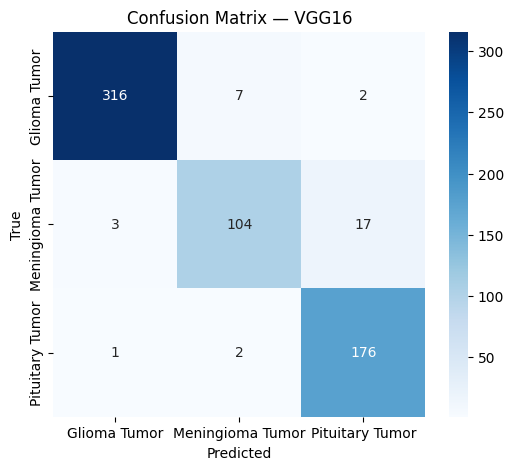

Fold: 4 block 2


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,628,363 (166.43 MB)

 Trainable params: 14,456,067 (55.15 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 28,912,136 (110.29 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9698 - loss: 0.0264
Epoch 1: val_accuracy improved from -inf to 0.95064, saving model to /kaggle/working/VGG16_block_2_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 403ms/step - accuracy: 0.9699 - loss: 0.0264 - val_accuracy: 0.9506 - val_loss: 0.0604 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9817 - loss: 0.0125
Epoch 2: val_accuracy did not improve from 0.95064
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.9817 - loss: 0.0125 - val_accuracy: 0.8885 - val_loss: 0.1616 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9817 - loss: 0.0186
Epoch 3: val_accuracy did not improve from 0.95064
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9818 - loss: 0.0185 - val_accuracy: 0.9347 - val_loss: 0.0804 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9843 - loss: 0.0210

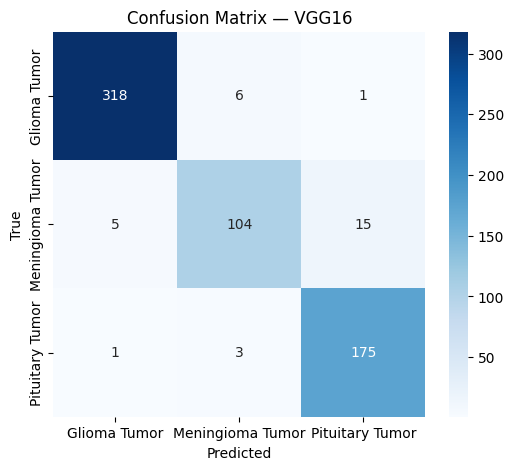

Fold: 4 block 1


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,071,243 (168.12 MB)

 Trainable params: 14,677,507 (55.99 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 29,355,016 (111.98 MB)

None
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9785 - loss: 0.0205
Epoch 1: val_accuracy improved from -inf to 0.92834, saving model to /kaggle/working/VGG16_block_1_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 48s 468ms/step - accuracy: 0.9785 - loss: 0.0205 - val_accuracy: 0.9283 - val_loss: 0.1123 - learning_rate: 1.0000e-05
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9769 - loss: 0.0146
Epoch 2: val_accuracy did not improve from 0.92834
78/78 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.9770 - loss: 0.0146 - val_accuracy: 0.9124 - val_loss: 0.2179 - learning_rate: 1.0000e-05
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9819 - loss: 0.0119
Epoch 3: val_accuracy improved from 0.92834 to 0.94427, saving model to /kaggle/working/VGG16_block_1_fold_4.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.9820 - loss: 0.0119 - val_accuracy: 0.9443 - val_loss: 0.0679 - learning_rate: 1.0000e-05
Epoch 4/50
78/78 ━━━━

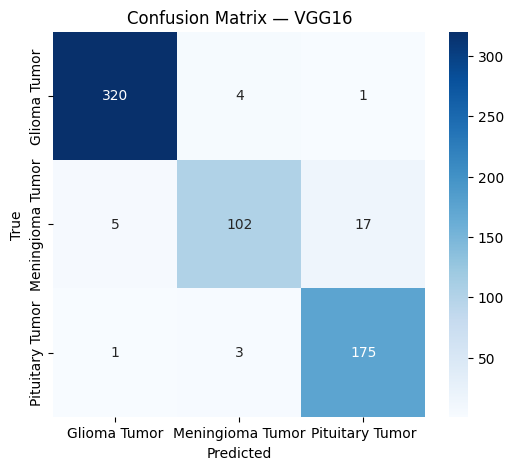

Fold: 5 block 6
Found 643 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,227 (56.14 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.4224 - loss: 2.5205
Epoch 1: val_accuracy improved from -inf to 0.68740, saving model to /kaggle/working/VGG16_block_6_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 27s 258ms/step - accuracy: 0.4237 - loss: 2.5116 - val_accuracy: 0.6874 - val_loss: 0.8775 - learning_rate: 0.0010
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6935 - loss: 0.8909
Epoch 2: val_accuracy improved from 0.68740 to 0.74028, saving model to /kaggle/working/VGG16_block_6_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 183ms/step - accuracy: 0.6935 - loss: 0.8902 - val_accuracy: 0.7403 - val_loss: 0.7693 - learning_rate: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7611 - loss: 0.6083
Epoch 3: val_accuracy did not improve from 0.74028
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.7610 - loss: 0.6081 - val_accuracy: 0.7341 - val_loss: 0.7610 - learning_rate: 0.0010
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━

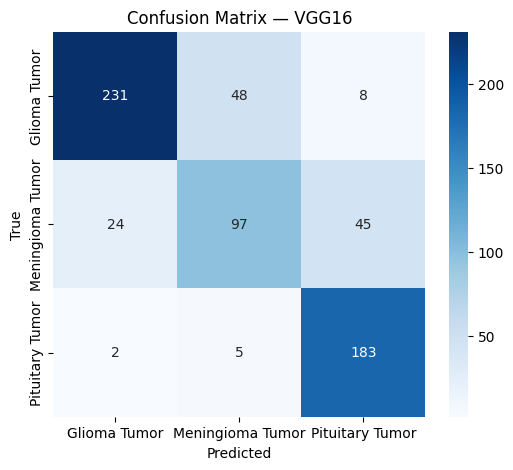

Fold: 5 block 5


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,307 (56.15 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 3,080 (12.04 KB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8227 - loss: 0.1816
Epoch 1: val_accuracy improved from -inf to 0.77449, saving model to /kaggle/working/VGG16_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 276ms/step - accuracy: 0.8229 - loss: 0.1813 - val_accuracy: 0.7745 - val_loss: 0.4758 - learning_rate: 1.0000e-05
Epoch 2/50
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8753 - loss: 0.1198
Epoch 2: val_accuracy improved from 0.77449 to 0.81649, saving model to /kaggle/working/VGG16_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.8753 - loss: 0.1196 - val_accuracy: 0.8165 - val_loss: 0.3689 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8990 - loss: 0.0842
Epoch 3: val_accuracy improved from 0.81649 to 0.82893, saving model to /kaggle/working/VGG16_block_5_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 182ms/step - accuracy: 0.8991 - loss: 0.0842 - val_accuracy: 0.8289 - va

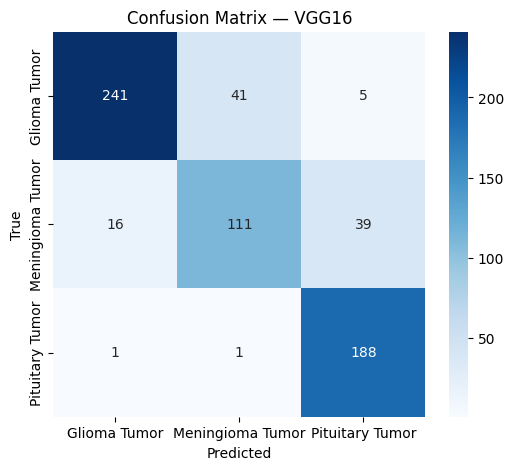

Fold: 5 block 4


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,878,155 (110.16 MB)

 Trainable params: 7,080,963 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,161,928 (54.02 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9340 - loss: 0.0619
Epoch 1: val_accuracy improved from -inf to 0.81337, saving model to /kaggle/working/VGG16_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 34s 323ms/step - accuracy: 0.9339 - loss: 0.0619 - val_accuracy: 0.8134 - val_loss: 0.4238 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9403 - loss: 0.0547
Epoch 2: val_accuracy improved from 0.81337 to 0.85692, saving model to /kaggle/working/VGG16_block_4_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.9403 - loss: 0.0547 - val_accuracy: 0.8569 - val_loss: 0.2892 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9527 - loss: 0.0363
Epoch 3: val_accuracy did not improve from 0.85692
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 182ms/step - accuracy: 0.9527 - loss: 0.0363 - val_accuracy: 0.8507 - val_loss: 0.4588 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━

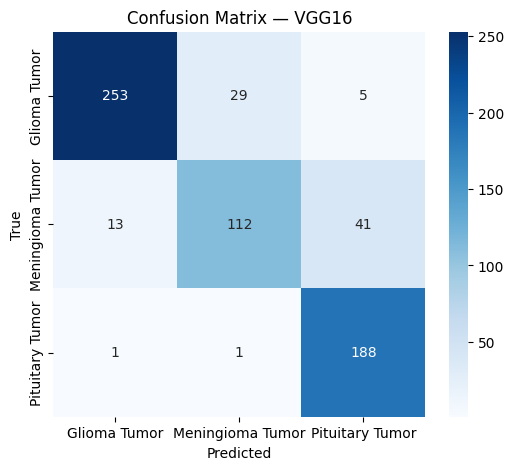

Fold: 5 block 3


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,677,707 (155.17 MB)

 Trainable params: 12,980,739 (49.52 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 25,961,480 (99.04 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9608 - loss: 0.0321
Epoch 1: val_accuracy improved from -inf to 0.84603, saving model to /kaggle/working/VGG16_block_3_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 367ms/step - accuracy: 0.9608 - loss: 0.0321 - val_accuracy: 0.8460 - val_loss: 0.4893 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9755 - loss: 0.0193
Epoch 2: val_accuracy improved from 0.84603 to 0.84914, saving model to /kaggle/working/VGG16_block_3_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - accuracy: 0.9755 - loss: 0.0193 - val_accuracy: 0.8491 - val_loss: 0.5413 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9740 - loss: 0.0249
Epoch 3: val_accuracy improved from 0.84914 to 0.87403, saving model to /kaggle/working/VGG16_block_3_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.9740 - loss: 0.0249 - val_accuracy: 0.8740 - va

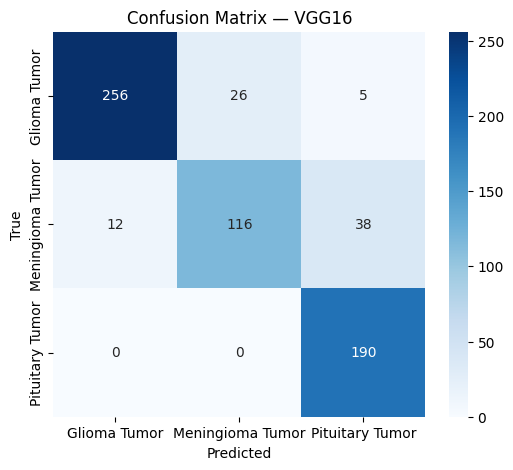

Fold: 5 block 2


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,628,363 (166.43 MB)

 Trainable params: 14,456,067 (55.15 MB)

 Non-trainable params: 260,160 (1016.25 KB)

 Optimizer params: 28,912,136 (110.29 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9775 - loss: 0.0212
Epoch 1: val_accuracy improved from -inf to 0.84603, saving model to /kaggle/working/VGG16_block_2_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 406ms/step - accuracy: 0.9775 - loss: 0.0212 - val_accuracy: 0.8460 - val_loss: 0.6956 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9760 - loss: 0.0280
Epoch 2: val_accuracy improved from 0.84603 to 0.86470, saving model to /kaggle/working/VGG16_block_2_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 223ms/step - accuracy: 0.9760 - loss: 0.0280 - val_accuracy: 0.8647 - val_loss: 0.4396 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9893 - loss: 0.0103
Epoch 3: val_accuracy improved from 0.86470 to 0.87558, saving model to /kaggle/working/VGG16_block_2_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step - accuracy: 0.9893 - loss: 0.0103 - val_accuracy: 0.8756 - va

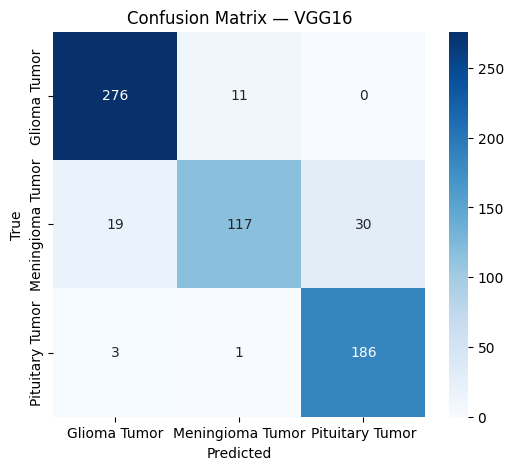

Fold: 5 block 1


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,071,243 (168.12 MB)

 Trainable params: 14,677,507 (55.99 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 29,355,016 (111.98 MB)

None
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9818 - loss: 0.0173
Epoch 1: val_accuracy improved from -inf to 0.82115, saving model to /kaggle/working/VGG16_block_1_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 47s 466ms/step - accuracy: 0.9818 - loss: 0.0173 - val_accuracy: 0.8212 - val_loss: 0.7023 - learning_rate: 1.0000e-05
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9814 - loss: 0.0144
Epoch 2: val_accuracy improved from 0.82115 to 0.87558, saving model to /kaggle/working/VGG16_block_1_fold_5.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9815 - loss: 0.0143 - val_accuracy: 0.8756 - val_loss: 0.5540 - learning_rate: 1.0000e-05
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9819 - loss: 0.0125
Epoch 3: val_accuracy did not improve from 0.87558
77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - accuracy: 0.9819 - loss: 0.0125 - val_accuracy: 0.8663 - val_loss: 0.6103 - learning_rate: 1.0000e-05
Epoch 4/50
77/77 ━━━━

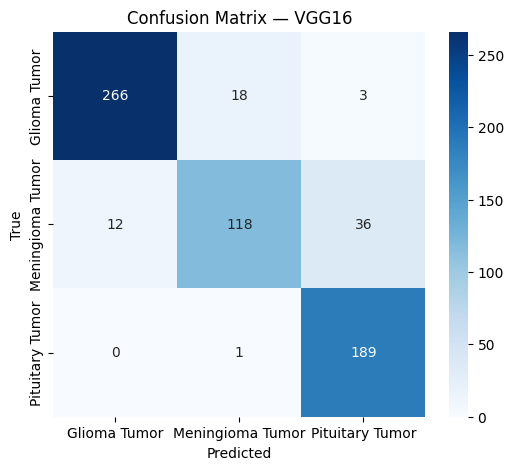

In [18]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_ds, val_ds = get_data_for_fold(fold_k, preprocess_fn)
    
    acc_b6.append(test_classifier(train_ds, val_ds, preprocess_fn, fold_k))
    tf.keras.backend.clear_session()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_ds, val_ds, preprocess_fn, fold_k, block))
        tf.keras.backend.clear_session()
        gc.collect()
    
    del train_ds, val_ds
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]
ACC_BLOCK

[[0.892988920211792,
  0.8379970788955688,
  0.867132842540741,
  0.8949044346809387,
  0.7947123050689697],
 [0.9335793256759644,
  0.8895434737205505,
  0.8968531489372253,
  0.918789803981781,
  0.8398133516311646],
 [0.9649446606636047,
  0.907216489315033,
  0.9178321957588196,
  0.941082775592804,
  0.8600311279296875],
 [0.9704797267913818,
  0.9175257682800293,
  0.9265734553337097,
  0.9490445852279663,
  0.8740279674530029],
 [0.9760147333145142,
  0.9337260723114014,
  0.9318181872367859,
  0.9506369233131409,
  0.9004665613174438],
 [0.9704797267913818,
  0.938144326210022,
  0.9248251914978027,
  0.9506369233131409,
  0.8911352753639221]]

In [20]:
for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 85.75%
Accuracy unfreeze block 5 - block 6: 89.57%
Accuracy unfreeze block 4 - block 6: 91.82%
Accuracy unfreeze block 3 - block 6: 92.75%
Accuracy unfreeze block 2 - block 6: 93.85%
Accuracy unfreeze block 1 - block 6: 93.50%
